# 02 — Preprocessing

**Phase 2.** The most consequential notebook (Planejamento §4): every choice here
affects the validity of all downstream results. It demonstrates the preprocessing
building blocks from `src/data/preprocessing.py` on the UCI dataset, with the
anti-leakage order enforced (DEVELOPMENT.md §6.2): **split → fit scaler on train →
SMOTE train only**, test never touched.

Label convention is **D-004**: 1 = phishing (positive), 0 = legitimate.

In [1]:
import sys
from pathlib import Path

_cwd = Path.cwd()
REPO_ROOT = _cwd if (_cwd / "src").exists() else _cwd.parent
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import PLOTS_EDA_DIR, PLOT_DPI, RANDOM_SEED
from src.data.loaders import load_raw
from src.data.preprocessing import (
    to_xy, split_data, apply_smote, fit_scaler, transform_features,
)
from src.utils.seeds import set_all_seeds

set_all_seeds(RANDOM_SEED)
%matplotlib inline
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = PLOT_DPI
print("setup ok")

setup ok


## 1. Load + label normalization (D-004)

`to_xy` splits features from the label and remaps UCI `Result` (-1 phishing / 1 legit) to the canonical {1 phishing, 0 legit}.

In [2]:
df = load_raw("uci")
X, y = to_xy(df, "uci")
print("X shape:", X.shape, "| n features:", X.shape[1])
print("\ny value counts (1=phishing, 0=legit):")
print(y.value_counts().sort_index().to_string())

# Prove the remap: raw Result vs normalized y.
proof = pd.crosstab(df["Result"], y)
proof.index.name = "Result (raw)"
proof.columns.name = "y (D-004)"
proof

X shape: (11055, 30) | n features: 30

y value counts (1=phishing, 0=legit):
Result
0    6157
1    4898


y (D-004),0,1
Result (raw),,
-1,0,4898
1,6157,0


## 2. Stratified 70/15/15 split (Planejamento §4.3)

Two successive stratified splits. The phishing share must stay ~constant across train/val/test (asserted inside `split_data`).

In [3]:
X_train, X_val, X_test, y_train, y_val, y_test = split_data(X, y)

rows = []
for name, ys in [("train", y_train), ("val", y_val), ("test", y_test), ("ALL", y)]:
    rows.append({
        "split": name, "n": len(ys),
        "%_of_total": round(100 * len(ys) / len(y), 1),
        "%_phishing": round(100 * ys.mean(), 1),
    })
pd.DataFrame(rows).set_index("split")

,n,%_of_total,%_phishing
split,,,
train,7738,70.0,44.3
val,1658,15.0,44.3
test,1659,15.0,44.3
ALL,11055,100.0,44.3


## 3. Why split BEFORE scaling and SMOTE (§6.2)

The single most common source of invalid results is leakage. The scaler is fit on **train only** and applied to val/test; SMOTE synthesizes samples from **train only**. The test set never influences any fitted transform, so its evaluation stays honest. Scaling precedes SMOTE so the synthetic-sample k-NN operates on comparably-scaled features.

train class counts BEFORE SMOTE:
Result
0    4310
1    3428

train class counts AFTER SMOTE:
Result
0    4310
1    4310

test set untouched: 1659 rows


saved plots/eda/uci_smote_before_after.png


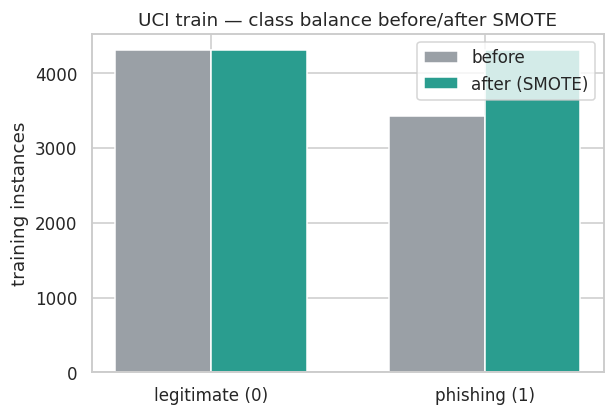

In [4]:
scaler = fit_scaler(X_train)
X_train_s = transform_features(scaler, X_train)
X_test_s = transform_features(scaler, X_test)

before = y_train.value_counts().sort_index()
X_train_res, y_train_res = apply_smote(X_train_s, y_train)
after = pd.Series(y_train_res).value_counts().sort_index()

print("train class counts BEFORE SMOTE:")
print(before.to_string())
print("\ntrain class counts AFTER SMOTE:")
print(after.to_string())

# The test set must be untouched by SMOTE (no resampling).
assert len(X_test_s) == len(y_test), "test size changed — leakage!"
print("\ntest set untouched:", len(y_test), "rows")

fig, ax = plt.subplots(figsize=(6, 4))
idx = np.arange(2); w = 0.35
ax.bar(idx - w / 2, [before.get(0, 0), before.get(1, 0)], w, label="before", color="#9aa0a6")
ax.bar(idx + w / 2, [after.get(0, 0), after.get(1, 0)], w, label="after (SMOTE)", color="#2a9d8f")
ax.set_xticks(idx); ax.set_xticklabels(["legitimate (0)", "phishing (1)"])
ax.set_ylabel("training instances")
ax.set_title("UCI train — class balance before/after SMOTE")
ax.legend()
PLOTS_EDA_DIR.mkdir(parents=True, exist_ok=True)
out = PLOTS_EDA_DIR / "uci_smote_before_after.png"
fig.savefig(out, dpi=PLOT_DPI, bbox_inches="tight")
print("saved", out.relative_to(REPO_ROOT))
plt.show()

## 4. Recap

The preprocessing contract used by every experiment: `to_xy` (label normalization) → `split_data` (stratified 70/15/15) → `fit_scaler` on train → `apply_smote` on train. The validation split is reserved for Phase 3 hyperparameter tuning; here it is created but unused.